In [1]:
import json
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix
import seaborn as sns
import kagglehub

COLUMNS = [
    'Time','isbA','isbB','isbC','ismA','ismB','ismC',
    'vsbA','vsbB','vsbC','vsmA','vsmB','vsmC',
    'isbARmsValue','isbBRmsValue','iisbCRmsValue',
    'ismARmsValue','ismBRmsValue','ismCRmsValue',
    'vsbARmsue','vsbBRmsValue','vsbCRmsValue',
    'vsmARmsValue','vsmBRmsValue','vsmCRmsValue',
    'isbATrapAreaSum','isbBTrapAreaSum','isbCTrapAreaSum',
    'ismATrapAreaSuValm','ismBTrapAreaSum','ismCTrapAreaSum',
    'vsbATrapAreaSum','vsbBTrapAreaSum','vsbCTrapAreaSum',
    'vsmATrapAreaSum','vsmBTrapAreaSum','vsmCTrapAreaSum',
    't','GooseTimestamp','SqNum','StNum','cbStatus','frameLen',
    'ethDst','ethSrc','ethType','gooseTimeAllowedtoLive',
    'gooseAppid','gooseLen','TPID','gocbRef','datSet','goID',
    'test','confRev','ndsCom','numDatSetEntries','APDUSize',
    'protocol','stDiff','sqDiff','gooseLengthDiff','cbStatusDiff',
    'apduSizeDiff','frameLengthDiff','timestampDiff',
    'tDiff','timeFromLastChange','delay','class'
]

# Download dataset and build paths
path = kagglehub.dataset_download("sequincozes/ereno-iec61850-ids")
train_df = pd.read_csv(os.path.join(path, "train.csv"), sep=',', skiprows=1, header=None, names=COLUMNS)
test_df  = pd.read_csv(os.path.join(path, "test.csv"),  sep=',', skiprows=1, header=None, names=COLUMNS)

# ── Column groups ──────────────────────────────────────────────────────────────
SV_INSTANTANEOUS = [
    'isbA','isbB','isbC',          # busbar currents
    'ismA','ismB','ismC',          # motor-side currents
    'vsbA','vsbB','vsbC',          # busbar voltages
    'vsmA','vsmB','vsmC',          # motor-side voltages
]
SV_RMS = [
    'isbARmsValue','isbBRmsValue','iisbCRmsValue',
    'ismARmsValue','ismBRmsValue','ismCRmsValue',
    'vsbARmsue',   'vsbBRmsValue','vsbCRmsValue',
    'vsmARmsValue','vsmBRmsValue','vsmCRmsValue',
]
SV_TRAP = [
    'isbATrapAreaSum','isbBTrapAreaSum','isbCTrapAreaSum',
    'ismATrapAreaSuValm','ismBTrapAreaSum','ismCTrapAreaSum',
    'vsbATrapAreaSum','vsbBTrapAreaSum','vsbCTrapAreaSum',
    'vsmATrapAreaSum','vsmBTrapAreaSum','vsmCTrapAreaSum',
]
GOOSE_FIELDS = [
    't','GooseTimestamp','SqNum','StNum','cbStatus','frameLen',
    'ethDst','ethSrc','ethType',
    'gooseTimeAllowedtoLive','gooseAppid','gooseLen','TPID',
    'gocbRef','datSet','goID','test','confRev','ndsCom',
    'numDatSetEntries','APDUSize','protocol',
]
DELTA_FEATURES = [
    'stDiff','sqDiff','gooseLengthDiff','cbStatusDiff',
    'apduSizeDiff','frameLengthDiff','timestampDiff',
    'tDiff','timeFromLastChange','delay',
]
LABEL_COL = 'class'

# ── Cleaning ───────────────────────────────────────────────────────────────────
train_df = train_df.dropna(axis=1)
test_df  = test_df.dropna(axis=1)

# Keep only columns present in both splits
shared_cols = [c for c in train_df.columns if c in test_df.columns]
train_df = train_df[shared_cols]
test_df  = test_df[shared_cols]

# ── Feature / label split ──────────────────────────────────────────────────────
X_train = train_df.drop(columns=[LABEL_COL])
y_train = train_df[LABEL_COL]
X_test  = test_df.drop(columns=[LABEL_COL])
y_test  = test_df[LABEL_COL]

# ── Identify numeric vs categorical columns ────────────────────────────────────
# Categorical: MAC addresses, ethType, protocol strings, flags, refs
KNOWN_CAT = ['ethDst','ethSrc','ethType','gooseAppid','TPID',
             'gocbRef','datSet','goID','test','ndsCom','protocol']

num_cols = [c for c in X_train.select_dtypes(include=[np.number]).columns
            if c not in KNOWN_CAT]
cat_cols = list(set(
    X_train.select_dtypes(include=['object']).columns.tolist() + KNOWN_CAT
) & set(X_train.columns))

# ── Scale numeric features ─────────────────────────────────────────────────────
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

# ── One-hot encode categorical features ───────────────────────────────────────
if cat_cols:
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    X_train_cat = encoder.fit_transform(X_train[cat_cols])
    X_test_cat  = encoder.transform(X_test[cat_cols])

    X_train = np.hstack([X_train[num_cols].values, X_train_cat])
    X_test  = np.hstack([X_test[num_cols].values,  X_test_cat])
else:
    X_train = X_train[num_cols].values
    X_test  = X_test[num_cols].values

# ── Encode labels ──────────────────────────────────────────────────────────────
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test  = le.transform(y_test)

# ── Sanity checks ──────────────────────────────────────────────────────────────
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"Classes: {list(le.classes_)}")
print(f"y_train distribution:\n{pd.Series(y_train).value_counts()}")
print(f"y_test distribution:\n{pd.Series(y_test).value_counts()}")

X_train shape: (2955738, 103)
X_test shape:  (2955648, 103)
Classes: ['high_StNum', 'injection', 'inverse_replay', 'masquerade_fake_fault', 'masquerade_fake_normal', 'normal', 'poisoned_high_rate', 'random_replay']
y_train distribution:
5    2759425
7      39000
1      39000
0      39000
2      26033
6      18574
4      17419
3      17287
Name: count, dtype: int64
y_test distribution:
5    2755139
7      39000
1      39000
0      39000
2      30319
6      18570
4      17420
3      17200
Name: count, dtype: int64


              precision    recall  f1-score   support

      normal       1.00      1.00      1.00   2755139
      attack       0.98      0.96      0.97    200509

    accuracy                           1.00   2955648
   macro avg       0.99      0.98      0.98   2955648
weighted avg       1.00      1.00      1.00   2955648



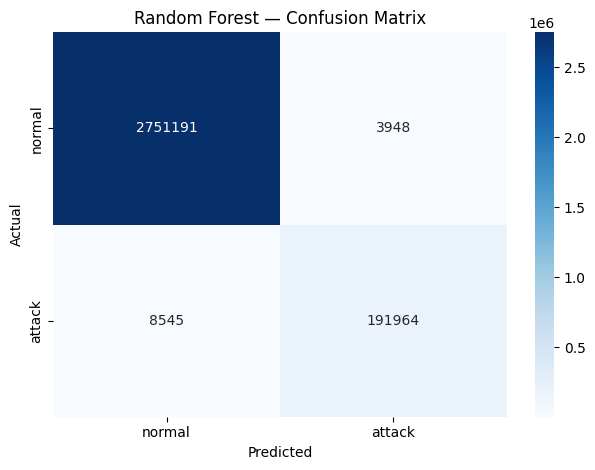

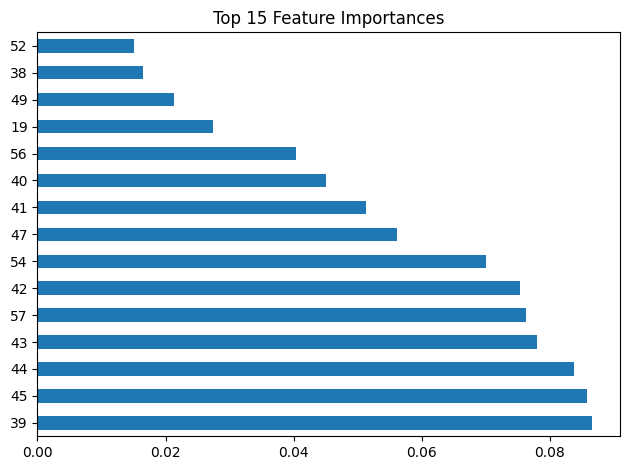

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ── Binarise labels: 1 = attack, 0 = normal ───────────────────────────────────
y_train_binary = (y_train != le.transform(['normal'])[0]).astype(int)
y_test_binary  = (y_test  != le.transform(['normal'])[0]).astype(int)

# ── Train ──────────────────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',  # handles class imbalance (attacks are rare)
    random_state=42,
    n_jobs=-1                 # use all CPU cores
)
rf.fit(X_train, y_train_binary)

# ── Evaluate ───────────────────────────────────────────────────────────────────
y_pred = rf.predict(X_test)

print(classification_report(y_test_binary, y_pred, target_names=['normal', 'attack']))

# ── Confusion matrix ───────────────────────────────────────────────────────────
cm = confusion_matrix(y_test_binary, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['normal', 'attack'],
            yticklabels=['normal', 'attack'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

# ── Top features ───────────────────────────────────────────────────────────────
feature_importance = pd.Series(rf.feature_importances_).nlargest(15)
feature_importance.plot(kind='barh', title='Top 15 Feature Importances')
plt.tight_layout()
plt.show()

Using device: cuda


Training Autoencoder:  17%|█▋        | 5/30 [01:02<05:12, 12.50s/it]

Epoch 5/30  loss: 0.000629


Training Autoencoder:  33%|███▎      | 10/30 [02:04<04:10, 12.50s/it]

Epoch 10/30  loss: 0.000385


...

Epoch 20/30  loss: 0.000281


Training Autoencoder:  83%|████████▎ | 25/30 [05:17<01:07, 13.50s/it]

Epoch 25/30  loss: 0.000240


Training Autoencoder: 100%|██████████| 30/30 [06:21<00:00, 12.72s/it]

Epoch 30/30  loss: 0.000218


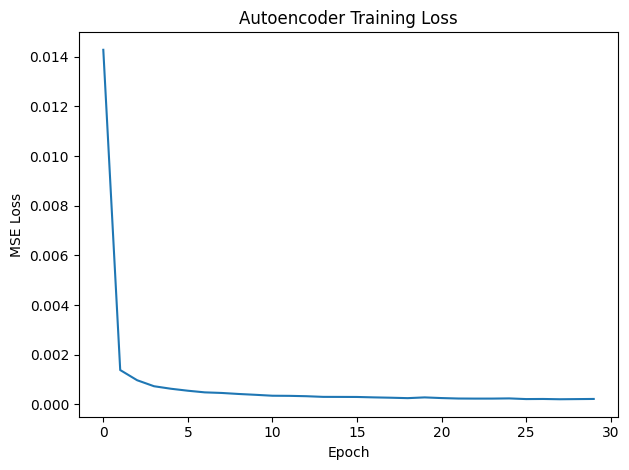

AUC-ROC: 0.9154
Optimal threshold: 0.014649


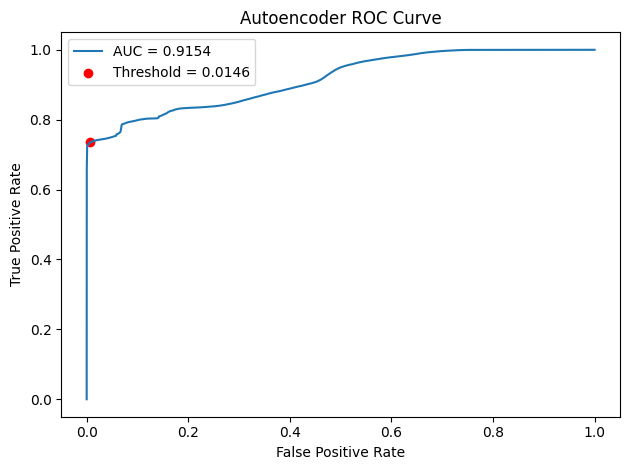

              precision    recall  f1-score   support

      normal       0.98      0.99      0.99   2755139
      attack       0.88      0.74      0.80    200509

    accuracy                           0.98   2955648
   macro avg       0.93      0.86      0.89   2955648
weighted avg       0.97      0.98      0.97   2955648



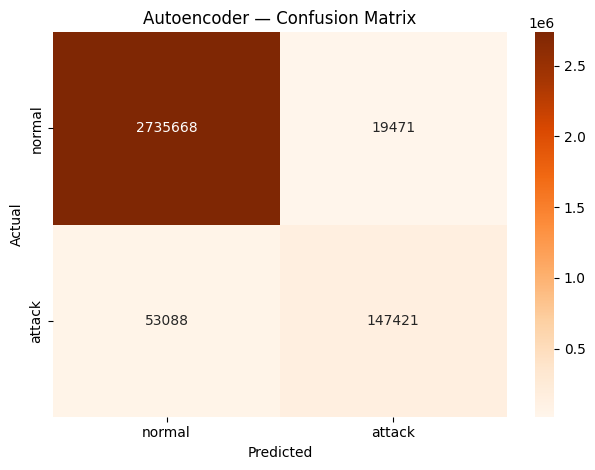

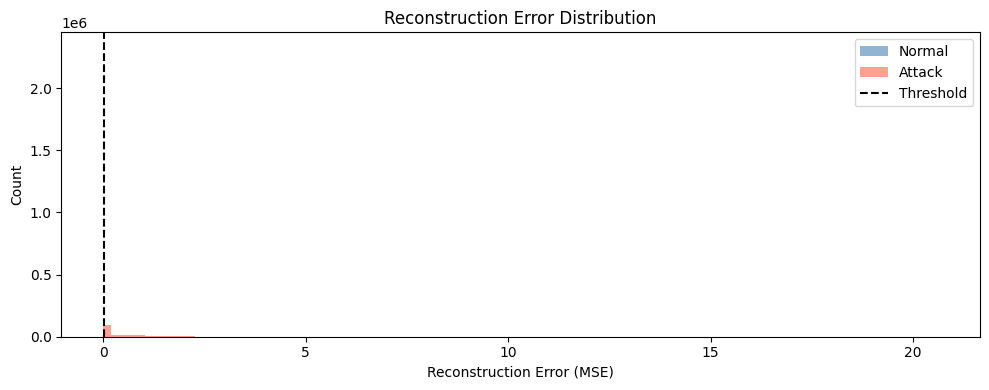

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
from tqdm import tqdm

# ── Build autoencoder ──────────────────────────────────────────────────────────
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

# ── Prepare data — train ONLY on normal traffic ────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

normal_idx = (y_train_binary == 0)
X_train_normal = X_train[normal_idx]

X_train_t  = torch.tensor(X_train_normal, dtype=torch.float32).to(device)
X_test_t   = torch.tensor(X_test,         dtype=torch.float32).to(device)

train_loader = DataLoader(TensorDataset(X_train_t), batch_size=512, shuffle=True)

# ── Train ──────────────────────────────────────────────────────────────────────
input_dim = X_train.shape[1]
model     = Autoencoder(input_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

EPOCHS = 30
train_losses = []

for epoch in tqdm(range(EPOCHS), desc="Training Autoencoder"):
    model.train()
    epoch_loss = 0
    for (batch,) in train_loader:
        optimizer.zero_grad()
        recon = model(batch)
        loss  = criterion(recon, batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(batch)
    avg_loss = epoch_loss / len(X_train_t)
    train_losses.append(avg_loss)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}  loss: {avg_loss:.6f}")

# ── Plot training loss ─────────────────────────────────────────────────────────
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training Loss")
plt.tight_layout()
plt.show()

# ── Reconstruction error on test set ──────────────────────────────────────────
model.eval()
with torch.no_grad():
    recon_test = model(X_test_t)
    recon_errors = ((X_test_t - recon_test) ** 2).mean(dim=1).cpu().numpy()

# ── Choose threshold via ROC curve ────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_test_binary, recon_errors)
auc = roc_auc_score(y_test_binary, recon_errors)
print(f"AUC-ROC: {auc:.4f}")

# Pick threshold closest to top-left of ROC curve (maximises TPR - FPR)
optimal_idx       = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal threshold: {optimal_threshold:.6f}")

plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', label=f"Threshold = {optimal_threshold:.4f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Autoencoder ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

# ── Evaluate at optimal threshold ─────────────────────────────────────────────
y_pred_ae = (recon_errors > optimal_threshold).astype(int)
print(classification_report(y_test_binary, y_pred_ae, target_names=['normal', 'attack']))

cm = confusion_matrix(y_test_binary, y_pred_ae)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['normal', 'attack'],
            yticklabels=['normal', 'attack'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Autoencoder — Confusion Matrix')
plt.tight_layout()
plt.show()

# ── Reconstruction error distribution ─────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.hist(recon_errors[y_test_binary == 0], bins=100, alpha=0.6, label='Normal',  color='steelblue')
plt.hist(recon_errors[y_test_binary == 1], bins=100, alpha=0.6, label='Attack',  color='tomato')
plt.axvline(optimal_threshold, color='black', linestyle='--', label='Threshold')
plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Count")
plt.title("Reconstruction Error Distribution")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.amp import autocast, GradScaler
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns

# ── Drop absolute Time column ──────────────────────────────────────────────────
time_col_idx = list(COLUMNS).index('Time')
X_train_nt = np.delete(X_train, time_col_idx, axis=1)
X_test_nt  = np.delete(X_test,  time_col_idx, axis=1)

# ── Lazy sequence dataset ──────────────────────────────────────────────────────
class SequenceDataset(Dataset):
    def __init__(self, X, y, seq_len, normal_only=False):
        self.X       = X.astype(np.float32)  # keep as numpy, just ensure correct dtype
        self.y       = y.astype(np.uint8)
        self.seq_len = seq_len

        attack      = self.y == 1
        window_sums = np.convolve(attack, np.ones(seq_len, dtype=np.uint8), mode='valid')
        valid       = window_sums[:len(X) - seq_len] == 0 if normal_only else np.ones(len(X) - seq_len, dtype=bool)
        self.indices = np.where(valid)[0]
        print(f"{'Normal-only' if normal_only else 'All'} sequences: {len(self.indices)}")

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i   = self.indices[idx]
        seq = self.X[i:i + self.seq_len]               # numpy slice — fast
        seq = torch.from_numpy(seq)                     # zero-copy conversion
        return seq[:-1], seq[1:]

    def get_label(self, idx):
        i = self.indices[idx]
        return 1 if self.y[i:i + self.seq_len].any() else 0

SEQ_LEN = 10

train_dataset = SequenceDataset(X_train_nt, y_train_binary, SEQ_LEN, normal_only=True)
test_dataset  = SequenceDataset(X_test_nt,  y_test_binary,  SEQ_LEN, normal_only=False)

print(f"Train sequences (normal only): {len(train_dataset)}")
print(f"Test sequences:                {len(test_dataset)}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True,
    num_workers=6,
    pin_memory=True,
    persistent_workers=True,   # workers stay alive between epochs
    prefetch_factor=4          # each worker prefetches 4 batches ahead
)
test_loader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=6,
    pin_memory=True,
    persistent_workers=True,   # workers stay alive between epochs
    prefetch_factor=4          # each worker prefetches 4 batches ahead
)

# ── Model ──────────────────────────────────────────────────────────────────────
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.output_layer = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.output_layer(out)

input_dim = X_train_nt.shape[1]
model     = LSTMAutoencoder(input_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# ── Train ──────────────────────────────────────────────────────────────────────
scaler = GradScaler("cuda")
EPOCHS = 30
train_losses = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for X_in, X_out in train_loader:
        X_in, X_out = X_in.to(device), X_out.to(device)
        optimizer.zero_grad()

        with autocast("cuda"):
            preds = model(X_in)
            loss  = criterion(preds, X_out)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)                                  # unscale before clipping
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item() * len(X_in)

    avg_loss = epoch_loss / len(train_dataset)
    train_losses.append(avg_loss)
    if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS}  loss: {avg_loss:.6f}  "
                  f"GPU mem: {torch.cuda.memory_allocated()/1e9:.2f}GB / "
                  f"{torch.cuda.get_device_properties(0).total_memory/1e9:.2f}GB")

plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Autoencoder Training Loss")
plt.tight_layout()
plt.show()

# ── Evaluate in batches ────────────────────────────────────────────────────────
model.eval()
recon_errors = []
y_test_seq   = []

with torch.no_grad():
    for batch_idx, (X_in, X_out) in enumerate(test_loader):
        X_in, X_out = X_in.to(device), X_out.to(device)
        preds       = model(X_in)
        error       = ((X_out - preds) ** 2).mean(dim=(1, 2))
        recon_errors.append(error.cpu().numpy())

        # Recover labels for this batch
        start = batch_idx * test_loader.batch_size
        end   = start + len(X_in)
        y_test_seq.extend([test_dataset.get_label(i) for i in range(start, end)])

recon_errors = np.concatenate(recon_errors)
y_test_seq   = np.array(y_test_seq)

# ── Threshold via ROC ──────────────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_test_seq, recon_errors)
auc = roc_auc_score(y_test_seq, recon_errors)
print(f"AUC-ROC: {auc:.4f}")

optimal_idx       = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal threshold: {optimal_threshold:.6f}")

plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', label=f"Threshold = {optimal_threshold:.4f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("LSTM Autoencoder ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

# ── Classification report & confusion matrix ───────────────────────────────────
y_pred = (recon_errors > optimal_threshold).astype(int)
print(classification_report(y_test_seq, y_pred, target_names=['normal', 'attack']))

cm = confusion_matrix(y_test_seq, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['normal', 'attack'],
            yticklabels=['normal', 'attack'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('LSTM Autoencoder — Confusion Matrix')
plt.tight_layout()
plt.show()

# ── Reconstruction error distribution ─────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.hist(recon_errors[y_test_seq == 0], bins=100, alpha=0.6, label='Normal', color='steelblue')
plt.hist(recon_errors[y_test_seq == 1], bins=100, alpha=0.6, label='Attack', color='tomato')
plt.axvline(optimal_threshold, color='black', linestyle='--', label='Threshold')
plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Count")
plt.title("LSTM Autoencoder — Reconstruction Error Distribution")
plt.legend()
plt.tight_layout()
plt.show()

Normal-only sequences: 2759020
All sequences: 2955638
Train sequences (normal only): 2759020
Test sequences:                2955638
Using device: cuda
